# SHAP analysis — DeepSHAP + post-hoc aggregation (|SHAP| per feature)

This notebook reads **per-feature DeepSHAP** artefacts only (`artifacts/shap/…`). Group-level numbers are built **after** attribution:

- Each row of `shap_mean.parquet` is one feature $f$ at one date $t$ and maturity $m$, with `abs_mean_shap` $= \bigl|\overline{\text{SHAP}}^{\,\text{seed}}_{f,m,t}\bigr|$ (absolute value of the top-$k$ seed **mean** SHAP).
- For an economic block $G$ (forward curve or a FRED-MD theme), we define **gross block activity**
  \[
  \mathcal{A}_{G,m}(t) \;= \;\sum_{f \in G} \bigl|\overline{\text{SHAP}}_{f,m,t}\bigr|.
  \]
- **Shares** and time series normalize $\mathcal{A}_{G,m}(t)$ across blocks so they sum to 100% at each $(m,t)$. The composition figure uses $\mathbb{E}_t[\mathcal{A}_{G,m}(t)]$ then row-normalises, matching the spirit of the group-Shapley notebook but with **feature-level game + gross aggregation**.

**Model switch.** Set `MODEL` in the loader cell. **No group-Shapley** — recompute is not required if `notebooks/shap/shap_compute.ipynb` has already written `shap_mean.parquet` / `per_seed_shap.parquet`.

**Contents.** (1) Composition 2Y & 10Y — (2) Bianchi-style ranking + group pie — (3) macro vs forwards over time (one panel per maturity, same `MODEL`) — (4) per-block shares over time — (5) seed stability from `per_seed_shap`.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo root: cwd may be repo root, notebooks/, or notebooks/shap/
REPO_ROOT = Path.cwd()
for _ in range(5):
    if (REPO_ROOT / 'utils' / 'base_utils.py').exists():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError('Could not find repo root (utils/base_utils.py).')
sys.path.insert(0, str(REPO_ROOT))

import utils.base_utils as bu
from utils.macro_grouping import add_group_level, build_full_group_mapping

start_date = '1971-08-31'
end_date = '2018-12-31'

yields = bu.get_yields(type='lw', start=start_date, end=end_date,
                       maturities=[str(i) for i in range(12, 121) if i % 12 == 0])
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna()

fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data(str(REPO_ROOT / 'data' / '2026-01-MD.csv'),
                               start=fred_md_start_date, end=end_date)

fred_md = fred_md_raw.shift(1)
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
fred_md = fred_md[start_date:end_date]

yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1, keys=['fred', 'forward', 'yields'])
X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')

dates = xr.index
print('X shape:', X.shape, '| dates:', dates[0].date(), '->', dates[-1].date())

X shape: (557, 144) | dates: 1971-08-31 -> 2017-12-31


/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


## Loader — DeepSHAP artefacts only

`MODEL` maps to an orchestrator run name under `artifacts/shap/`; below we open the **latest timestamped folder** for that run and load **`shap_mean.parquet`** (and **`per_seed_shap.parquet`** if present).

**Code.** Aggregates **per-feature** `abs_mean_shap` into **block_mass** `(maturity × date × block)` by summing `|mean_seed SHAP|` within each block on each row. Builds **BLOCK_ORDER** and colour maps for plotting later cells.


In [2]:
# ── Model selector ───────────────────────────────────────────────────────
MODEL = 'macro_forward'         # 'macro_forward' | 'group_ensemble'
MATS_PRIMARY = ['24', '120']    # 2Y and 10Y
# ─────────────────────────────────────────────────────────────────────────

RUN_NAME = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}[MODEL]

DEEP_SHAP_ROOT = REPO_ROOT / 'artifacts' / 'shap' / RUN_NAME

def _latest_ts(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f'No artefacts under {root}. Run shap compute first.')
    stamps = sorted(p for p in root.iterdir() if p.is_dir())
    if not stamps:
        raise FileNotFoundError(f'No timestamped runs under {root}')
    return stamps[-1]

ds_dir = _latest_ts(DEEP_SHAP_ROOT)
sm = pd.read_parquet(ds_dir / 'shap_mean.parquet')
sm['date'] = pd.to_datetime(sm['date'])
sm['maturity'] = sm['maturity'].astype(str)

per_seed_path = ds_dir / 'per_seed_shap.parquet'
if per_seed_path.exists():
    pss = pd.read_parquet(per_seed_path)
    pss['date'] = pd.to_datetime(pss['date'])
    pss['maturity'] = pss['maturity'].astype(str)
else:
    pss = None


def parse_block(feat: str) -> str:
    parts = feat.split('::')
    if parts[0] == 'forward':
        return 'forward'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1]
    if len(parts) >= 2:
        return parts[0]
    return parts[0]


def parse_display(feat: str) -> str:
    parts = feat.split('::')
    if parts[0] == 'forward':
        return f'fwd {parts[-1]}' if len(parts) > 1 else 'fwd'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[2]
    if len(parts) >= 2:
        return parts[1]
    return feat


sm = sm.assign(block=sm['feature'].map(parse_block))

# Per-(date, maturity, block): sum |mean_seed SHAP| over features in block.
block_mass = (
    sm.groupby(['maturity', 'date', 'block'], sort=False)['abs_mean_shap']
    .sum().reset_index(name='mass')
)

_macro_order = (
    block_mass[(block_mass['block'] != 'forward')
               & (block_mass['maturity'].isin(MATS_PRIMARY))]
    .groupby('block')['mass'].sum().sort_values(ascending=False).index.tolist()
)
BLOCK_ORDER = ['forward'] + _macro_order

_CLASSIC = ['#1f77b4', '#17becf', '#9467bd', '#2ca02c',
            '#bcbd22', '#ff7f0e', '#d62728', '#7f7f7f',
            '#8c564b', '#c5b0d5']
BLOCK_COLOURS = {'forward': '#3a4a5c'}
for i, g in enumerate(_macro_order):
    BLOCK_COLOURS[g] = _CLASSIC[i % len(_CLASSIC)]


print(f'MODEL = {MODEL!r}')


def block_label(b: str) -> str:
    return 'Forward rates' if b == 'forward' else b


print(f'  shap dir: {ds_dir.name}  |  rows={len(sm):,}  dates={sm["date"].nunique()}')
print(f'  maturities: {sorted(sm["maturity"].unique())}')
print(f'  blocks: {BLOCK_ORDER}')
print(f'  per_seed_shap: {"yes" if pss is not None else "NO — seed stability skipped"}')


MODEL = 'macro_forward'
  shap dir: 20260422_103724  |  rows=270,144  dates=336
  maturities: ['120', '24', '36', '48', '60', '84']
  blocks: ['forward', 'Labor Market', 'Housing', 'Interest and Exchange Rates', 'Prices', 'Output and Income', 'Money and Credit', 'Consumption, Orders, and Inventories', 'Stock Market']
  per_seed_shap: yes


## Composition

**Code.** For each maturity in **`MATS_PRIMARY`**, averages block masses over observation dates \(t\) to \(\mathbb{E}_t[\mathcal{A}_{g,m,t}]\), then divides by the sum across blocks so each maturity row sums to \(1\) (shown as percentages on the \(x\)-axis). Bars are plotted with **longer maturity at the bottom** of the stacked bar \(y\) order.

**Plot.** Two stacked **horizontal** bars — one maturity per row — colored by economic **block**. Read as: *steady-state* mix of pooled gross \(\sum |\overline{\text{SHAP}}|\) attributable to forwards vs macro themes **after averaging over time**. Legend sits below so it does not cover the stacks.


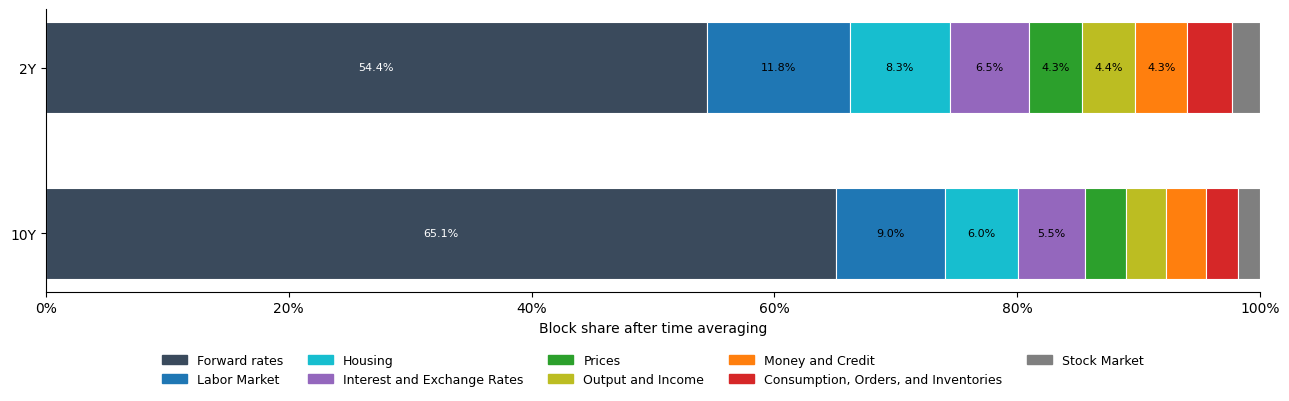


=== macro_forward · block shares (%) — mean_t Σ_f |SHAP| ===
maturity                                120     24
block                                             
forward                               65.06  54.41
Labor Market                           8.99  11.77
Housing                                6.00   8.28
Interest and Exchange Rates            5.53   6.52
Prices                                 3.40   4.33
Output and Income                      3.28   4.36
Money and Credit                       3.28   4.33
Consumption, Orders, and Inventories   2.63   3.68
Stock Market                           1.83   2.32


In [3]:
t1 = (
    block_mass[block_mass['maturity'].isin(MATS_PRIMARY)]
    .groupby(['maturity', 'block'])['mass'].mean()
    .unstack('block').reindex(columns=BLOCK_ORDER).fillna(0.0)
)
shares = t1.div(t1.sum(axis=1), axis=0)

_mats_bar = sorted(MATS_PRIMARY, key=lambda m: int(m), reverse=True)

fig, ax_bar = plt.subplots(figsize=(13, 4.25))
for i, mat in enumerate(_mats_bar):
    left = 0.0
    row = shares.loc[mat]
    for b in BLOCK_ORDER:
        w = float(row[b])
        if w <= 0:
            continue
        ax_bar.barh(i, w, left=left, color=BLOCK_COLOURS[b],
                    edgecolor='white', linewidth=0.8, height=0.55)
        if w >= 0.04:
            ax_bar.text(left + w / 2, i, f'{w*100:.1f}%', ha='center', va='center',
                        fontsize=8, color='white' if b == 'forward' else 'black')
        left += w

ax_bar.set_yticks(range(len(_mats_bar)))
ax_bar.set_yticklabels([f'{int(m)//12}Y' for m in _mats_bar])
ax_bar.set_xlim(0, 1)
ax_bar.set_xticks(np.linspace(0, 1, 6))
ax_bar.set_xticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
ax_bar.set_xlabel('Block share after time averaging')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in BLOCK_ORDER]
fig.tight_layout()
fig.subplots_adjust(bottom=0.30)
ax_bar.legend(
    handles, [block_label(b) for b in BLOCK_ORDER],
    loc='upper center', bbox_to_anchor=(0.5, -0.18),
    ncol=min(len(BLOCK_ORDER), 5), frameon=False, fontsize=9,
)
plt.show()

print()
print('=== ' + MODEL + ' · block shares (%) — mean_t Σ_f |SHAP| ===')
print(((shares * 100).round(2).T).to_string())


## Macro ranking

**Code.** Drops forwards; ranks **individual macro series** within each maturity using mean **importance** \(=\mathbb{E}_t[\,|\mathrm{mean\,SHAP}|\,]\) per feature (**top‑N** configurable). LHS bar widths are shares **among those top‑N macro features only** (they sum to 1 inside the LHS chart). RHS **donut** takes the same maturity’s macro block totals (from the composition aggregates), drops forwards, **renormalizes** wedges to 100\\% across FRED‑MD **groups**.

**Plot.** LHS = *which macro series* dominate the ranking mass; RHS = how that macro‑only mass splits across **thematic blocks**.


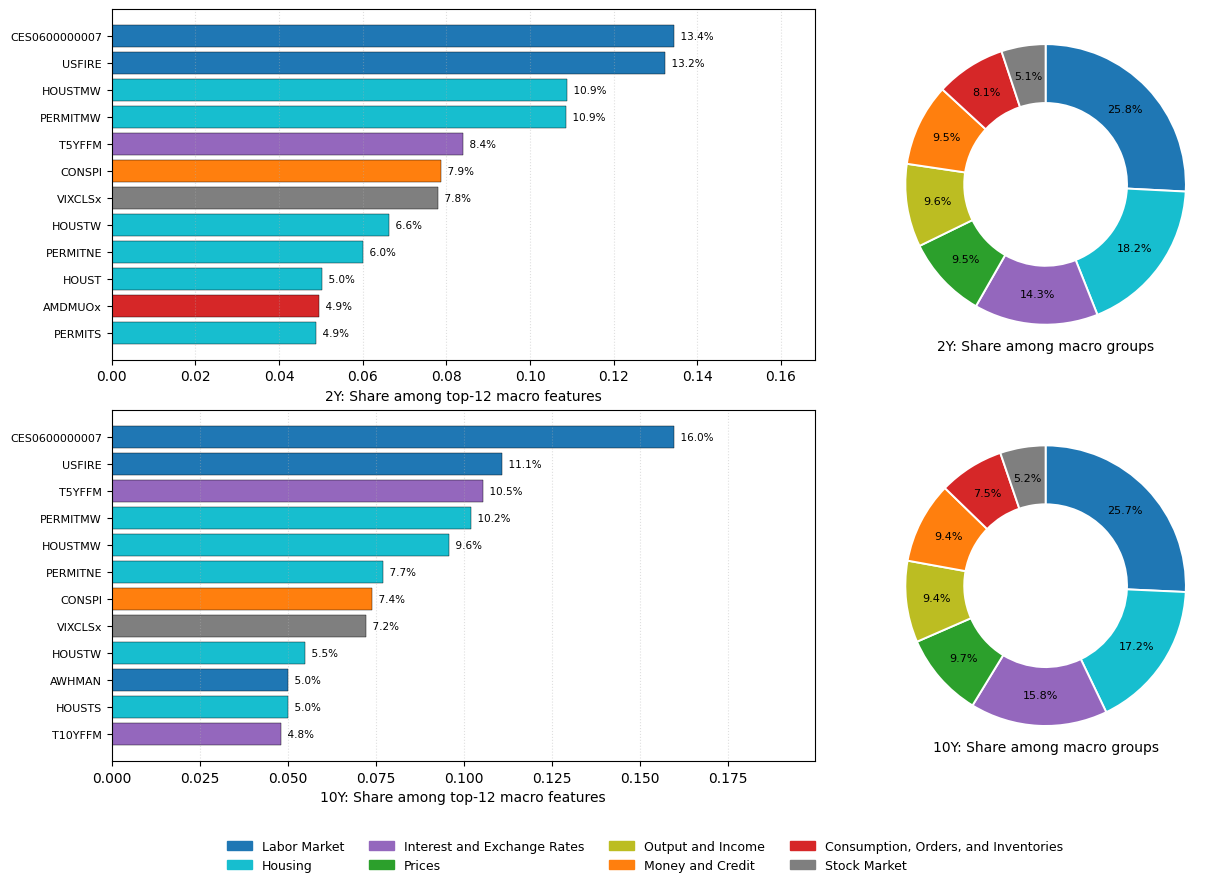

In [6]:
tier2_top_n = 12
tier2_label_pct_min = 3.0

sm_macro = sm[sm['block'] != 'forward'].copy()
sm_macro = sm_macro.assign(display=sm_macro['feature'].map(parse_display))
feat_imp = (
    sm_macro.groupby(['maturity', 'feature', 'block', 'display'])['abs_mean_shap']
    .mean().reset_index(name='importance')
)

fig, axes = plt.subplots(
    len(MATS_PRIMARY), 2,
    figsize=(13, 0.30 * tier2_top_n * len(MATS_PRIMARY) + 2.2),
    gridspec_kw={'width_ratios': [1.5, 1.0]},
    squeeze=False,
)
for i, mat in enumerate(MATS_PRIMARY):
    ax_l = axes[i, 0]
    sub = feat_imp[feat_imp['maturity'] == mat].nlargest(tier2_top_n, 'importance').copy()
    sub = sub.sort_values('importance', ascending=True)
    rel = sub['importance'] / sub['importance'].sum()
    colours = [BLOCK_COLOURS.get(b, '#999') for b in sub['block']]
    ax_l.barh(sub['display'], rel, color=colours, edgecolor='black', linewidth=0.3)
    for y, v in zip(sub['display'], rel):
        ax_l.text(v, y, f'  {v*100:.1f}%', va='center', fontsize=7.5)
    ax_l.set_xlim(0, rel.max() * 1.25)
    ax_l.set_xlabel(fr'{int(mat)//12}Y: Share among top-{tier2_top_n} macro features')
    ax_l.tick_params(axis='y', labelsize=8)
    ax_l.grid(axis='x', linestyle=':', alpha=0.4)

    ax_r = axes[i, 1]
    row = shares.loc[mat].drop('forward', errors='ignore')
    row = row / row.sum()
    colours_pie = [BLOCK_COLOURS[b] for b in row.index]
    _, _, autotexts = ax_r.pie(
        row.values, colors=colours_pie, startangle=90, counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=1.4),
        autopct=lambda p: f'{p:.1f}%' if p >= tier2_label_pct_min else '',
        pctdistance=0.78,
    )
    ax_r.text(
    0.5, 0.02,
    f'{int(mat)//12}Y: Share among macro groups',        # ← write whatever you want here
    transform=ax_r.transAxes,
    ha='center', va='bottom',
    fontsize=10               # no fontweight → not bold
) 

    for t in autotexts:
        t.set_fontsize(8)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in _macro_order]
plt.tight_layout()
fig.subplots_adjust(bottom=0.14, top=0.94)
fig.legend(
    handles, _macro_order, loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(len(_macro_order), 4), frameon=False, fontsize=9,
)
plt.show()


## Spanning (macro vs forwards)

**Code.** Computes a **daily series** \(\mathcal{A}_{\mathrm{macro}}/(\mathcal{A}_{\mathrm{macro}}+\mathcal{A}_{\mathrm{fwd}})\) from summed block masses (same **gross** DeepSHAP mass as elsewhere). Plot shows **monthly** values, optionally a moving average (default \(6\) months), dashed **sample mean**, grey **NBER recession** bands, repeated per maturity (`MATS_PRIMARY`).

**Plot.** Tracks whether “macro attribution” dominates **versus** forwards over calendar time \(t\) — the usual **single‑hypothesis spanning read** expressed in attribution space.


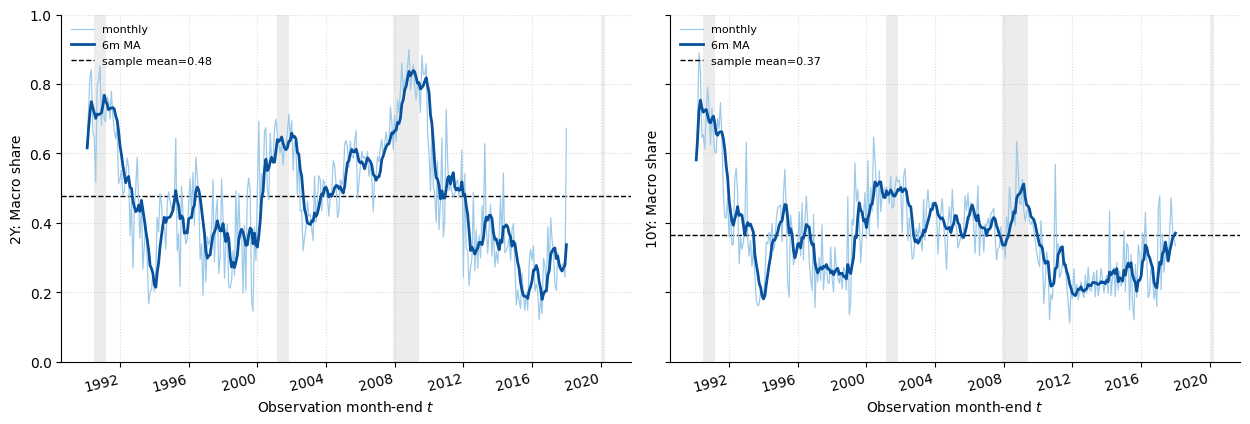


=== DeepSHAP macro share · macro_forward ===
2Y count    336.000
mean       0.477
std        0.177
min        0.120
25%        0.339
50%        0.480
75%        0.607
max        0.899
10Y count    336.000
mean       0.365
std        0.135
min        0.111
25%        0.266
50%        0.353
75%        0.441
max        0.890


In [7]:
# ── Spanning: DeepSHAP gross (same MODEL as loader; MATS_PRIMARY maturities) ──
span_ma_months = 6  # moving-average window (months); reference figures use 6m MA

nber_recessions = [
    ('1990-07-01', '1991-03-01'), ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'), ('2020-02-01', '2020-04-01'),
]
nber_recessions = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in nber_recessions]


def shade_recessions(ax, alpha=0.15, color='0.5'):
    y0, y1 = ax.get_ylim()
    for start, end in nber_recessions:
        ax.axvspan(start, end, facecolor=color, alpha=alpha, linewidth=0, zorder=0)
    ax.set_ylim(y0, y1)


def _macro_share_deep_from_block_mass(bm: pd.DataFrame, mat: str) -> pd.Series:
    sub = bm[bm['maturity'] == mat].copy()
    sub['kind'] = np.where(sub['block'] == 'forward', 'forward', 'macro')
    tot = sub.groupby(['date', 'kind'])['mass'].sum().unstack('kind').fillna(0.0)
    return (tot['macro'] / (tot['forward'] + tot['macro']).replace(0, np.nan)).sort_index()


def _plot_spanning_maturities(fig, axes, series_by_mat: dict, mat_keys: list):
    ax_list = np.asarray(axes, dtype=object).ravel().tolist()
    if len(ax_list) != len(mat_keys):
        raise ValueError(f'Expected {len(mat_keys)} axes, got {len(ax_list)}')
    for ax, mat in zip(ax_list, mat_keys):
        lbl = f'{int(mat)//12}Y'
        monthly = series_by_mat.get(mat, pd.Series(dtype=float))
        monthly = monthly.dropna().sort_index()
        if monthly.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            ax.set_ylabel(f'Macro share ({lbl})')
            ax.set_xlabel(r'Observation month-end $t$', fontsize=10)
            continue
        ma = monthly.rolling(span_ma_months, min_periods=1).mean()
        mean_v = float(monthly.mean())
        ax.plot(monthly.index, monthly, color='#9ecae9', linewidth=0.9, label='monthly', zorder=2)
        ax.plot(ma.index, ma, color='#08519c', linewidth=2.0, label=f'{span_ma_months}m MA', zorder=3)
        ax.axhline(mean_v, color='black', linestyle='--', linewidth=1.0,
                   label=f'sample mean={mean_v:.2f}', zorder=1)
        shade_recessions(ax)
        ax.set_ylim(0, 1)
        ax.set_ylabel(
            f'{lbl}: Macro share',
            fontsize=10,
        )
        ax.legend(frameon=False, loc='upper left', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlabel(r'Observation month-end $t$')
    fig.autofmt_xdate(rotation=14, ha='right')
    fig.tight_layout()


deep_ts_by_mat = {m: _macro_share_deep_from_block_mass(block_mass, m) for m in MATS_PRIMARY}

fig1, axes1 = plt.subplots(
    1, len(MATS_PRIMARY), figsize=(6.3 * len(MATS_PRIMARY), 4.35), sharey=True, squeeze=False,
)
_plot_spanning_maturities(
    fig1,
    axes1,
    deep_ts_by_mat,
    list(MATS_PRIMARY),
)

plt.show()

print()
print('=== DeepSHAP macro share · ' + MODEL + ' ===')
for mat, s in deep_ts_by_mat.items():
    print(f'{int(mat)//12}Y', s.describe().round(3).to_string())


## Block shares over time

**Code.** Each date sums block masses to \(\mathcal{A}_{g,m}(t)\) and divides by \(\sum_{g'}\mathcal{A}_{g',m}(t)\) so block **shares sum to \(1\)** cross‑sectionally (\(100\\%\) stacks). Applies a configurable **rolling mean** smooth (default \(12\) months) so the stack is readable.

**Plot.** **Area chart** stacked to 100\\% \(y\) as a function of month‑end \(t\) — temporal evolution of *which themes matter when*, not steady‑state averages from the composition figure.


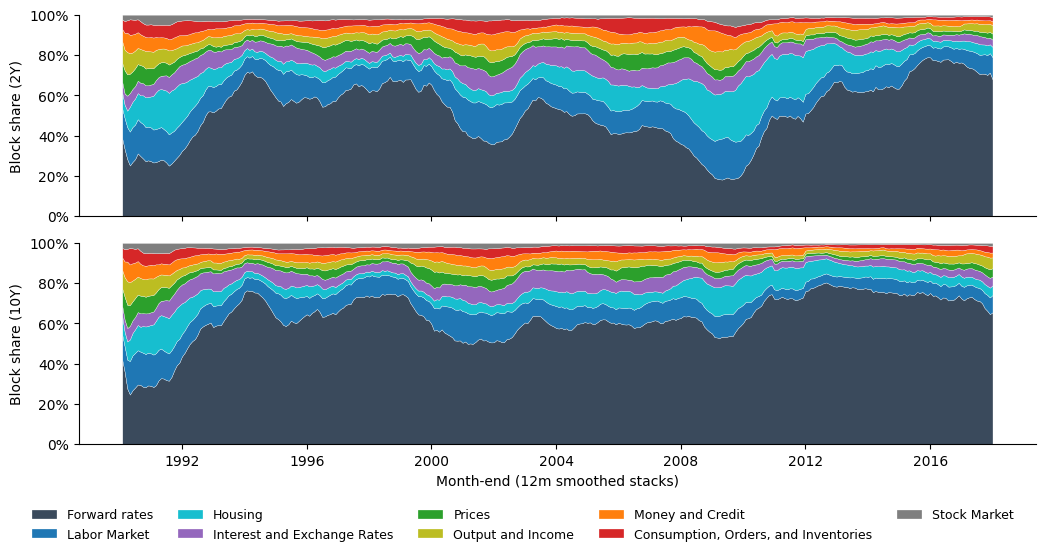

In [ ]:
tier4_smoothing = 6

def _block_shares_ts(mat: str) -> pd.DataFrame:
    sub = block_mass[block_mass['maturity'] == mat]
    wide = (
        sub.pivot_table(index='date', columns='block', values='mass', aggfunc='sum')
        .reindex(columns=BLOCK_ORDER).fillna(0.0)
    )
    wide = wide.div(wide.sum(axis=1).replace(0, np.nan), axis=0)
    if tier4_smoothing > 1:
        wide = wide.rolling(tier4_smoothing, min_periods=1).mean()
    return wide.sort_index()

fig, axes = plt.subplots(
    len(MATS_PRIMARY), 1, figsize=(12, 3.0 * len(MATS_PRIMARY)), sharex=True,
)
if len(MATS_PRIMARY) == 1:
    axes = [axes]

for ax, mat in zip(axes, MATS_PRIMARY):
    df = _block_shares_ts(mat)
    ax.stackplot(
        df.index, df[BLOCK_ORDER].T.values,
        colors=[BLOCK_COLOURS[b] for b in BLOCK_ORDER],
        labels=[block_label(b) for b in BLOCK_ORDER],
        edgecolor='white', linewidth=0.2,
    )
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
    ax.set_ylabel(f'Block share ({int(mat)//12}Y)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout(rect=[0.06, 0.06, 0.94, 0.93])

fig.legend(
    handles, labels,
    ncol=min(len(BLOCK_ORDER), 5),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    frameon=False,
    fontsize=9,
)

axes[-1].set_xlabel(f'Month-end ({tier4_smoothing}m smoothed stacks)')

fig.subplots_adjust(bottom=0.18)
plt.show()


## Seed dispersion

**Code.** If **`per_seed_shap.parquet`** exists from the DeepSHAP run, aggregates **within each train seed \(s\)** the same \(\mathbb{E}_t| \mathrm{SHAP} |\)‑style totals per block, then computes **block fractions** \(\bar{\mathcal{A}}^{(s)}_{G}/\sum_{G'}\bar{\mathcal{A}}^{(s)}_{G'}\). Scatter points jitter by block row; **`|\`** marker = ensemble mean from **`shap_mean`** block totals for comparison.

**Plot.** Dispersion of thematic shares across **random seeds**: wide spread \(\Rightarrow\) training instability for that theme; tight \(\Rightarrow\) stable macro vs forward decomposition **after averaging over time inside each seed**.


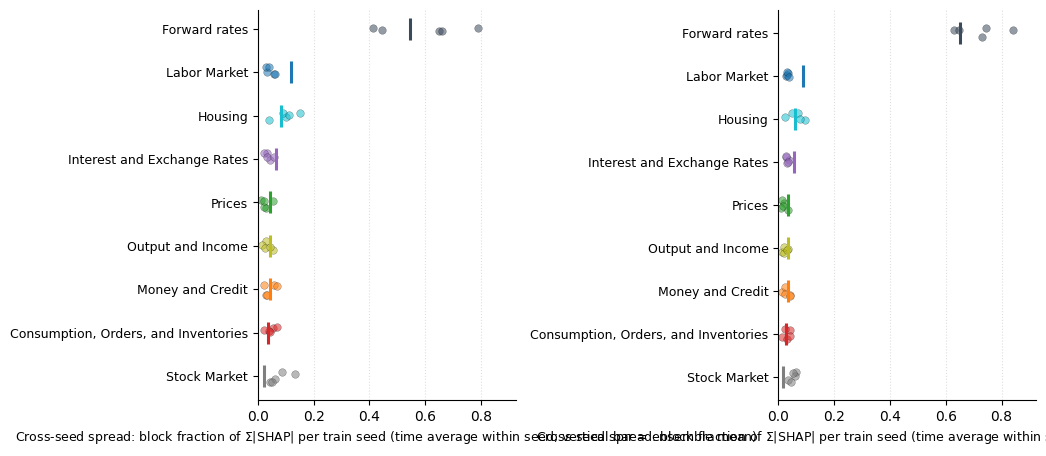


=== macro_forward · across-seed SD of share (%) ===
          Forward rates  Labor Market  Housing  Interest and Exchange Rates  Prices  Output and Income  Money and Credit  Consumption, Orders, and Inventories  Stock Market
maturity                                                                                                                                                                    
120                7.53          0.42     2.48                         0.38    0.85               0.80              1.15                                  1.03          1.10
24                14.10          1.28     3.59                         1.16    1.39               1.36              1.79                                  1.52          3.22


In [ ]:
if pss is None:
    print('Skipping seed stability: per_seed_shap.parquet not found. Re-run SHAP with save_per_seed=True.')
else:
    pss2 = pss[pss['maturity'].isin(MATS_PRIMARY)].copy()
    pss2['block'] = pss2['feature'].map(parse_block)
    pss2['abs_shap'] = pss2['shap_value'].abs()

    seed_mass = (
        pss2.groupby(['maturity', 'seed', 'block'])['abs_shap']
        .mean().reset_index(name='mass')
    )
    seed_mass['denom'] = seed_mass.groupby(['maturity', 'seed'])['mass'].transform('sum')
    seed_mass['share'] = seed_mass['mass'] / seed_mass['denom']

    ens = (
        block_mass[block_mass['maturity'].isin(MATS_PRIMARY)]
        .groupby(['maturity', 'block'])['mass'].mean().reset_index()
    )
    ens['denom'] = ens.groupby('maturity')['mass'].transform('sum')
    ens['share'] = ens['mass'] / ens['denom']

    fig, axes = plt.subplots(
        1, len(MATS_PRIMARY),
        figsize=(6.0 * len(MATS_PRIMARY), 0.45 * len(BLOCK_ORDER) + 1.5),
        sharex=True,
    )
    if len(MATS_PRIMARY) == 1:
        axes = [axes]

    rng = np.random.default_rng(0)
    for ax, mat in zip(axes, MATS_PRIMARY):
        for yi, g in enumerate(BLOCK_ORDER[::-1]):
            sdf = seed_mass[(seed_mass['maturity'] == mat) & (seed_mass['block'] == g)]
            if not sdf.empty:
                jitter = rng.uniform(-0.14, 0.14, size=len(sdf))
                ax.scatter(
                    sdf['share'].values, yi + jitter,
                    color=BLOCK_COLOURS[g], alpha=0.55, s=30,
                    edgecolor='black', linewidth=0.25,
                )
            erow = ens[(ens['maturity'] == mat) & (ens['block'] == g)]
            if not erow.empty:
                ax.scatter(erow['share'].values, [yi], color=BLOCK_COLOURS[g],
                           marker='|', s=260, linewidth=2.2)
        ax.set_yticks(range(len(BLOCK_ORDER)))
        ax.set_yticklabels([block_label(b) for b in BLOCK_ORDER[::-1]], fontsize=9)
        ax.set_xlim(0, max(0.7, float(seed_mass['share'].max()) * 1.1))
        ax.set_xlabel(
            f'{int(mat)//12}Y: Block fraction of $\Sigma|\mathrm{SHAP}|$ per train seed '
            fontsize='10',
        )
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle=':', alpha=0.4)

    fig.tight_layout(rect=[0.06, 0.10, 0.94, 0.94])
    plt.show()

    sd_tbl = (
        seed_mass.groupby(['maturity', 'block'])['share']
        .std(ddof=0).mul(100).round(2).unstack('block')[BLOCK_ORDER]
    )
    sd_tbl.columns = [block_label(c) for c in sd_tbl.columns]
    print()
    print('=== ' + MODEL + ' · across-seed SD of share (%) ===')
    print(sd_tbl.to_string())
